In [ ]:
# created for physics report on a Multi-Tuned Mass Damper system and its realtive stability compared to mono-mass systems.

## overall steps
# Collect and parse data (2*n + 3)
# synchronize time stamp 
# Setup accel_calib
# calculate RMS and NRMSE/NRSE
# plot graphs and relative RMS flex and transmission trend
# print results


## steps that didn't work out

# turns out driven random vibrations are pretty hard to sinfit

#sinfit each data 1 (use FFT)
#setup percentile contraint
#best fit and NRMSE/NRSE driver wave
#extract acc_ of second wave
#relative acc_ of wave 2's
#integrate and detrend

# no meaningful results, the phase shifts seemed random

#plot frequency drift FFT
#plot KE analysis (KE setup - KE Wave 2)
#gauge stability factor (Average of KE)

In [ ]:
## SETUP & CONFIG

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.signal import medfilt, butter, filtfilt, hilbert
from scipy.integrate import cumulative_trapezoid
from scipy.signal import detrend

# Global parameters
MASS = 0.200  # kg - mass of system
f=[1.63,1.44] #high, low Hz
w_h = 2*np.pi*f[0]
w_l = 2*np.pi*f[1]

f_bound = (1.0, 1.8) # Hz - expected frequency range for fitting

W_BOUNDS = (2*np.pi*f_bound[0], 2*np.pi*f_bound[1])  # rad/s - expected frequency range
SYNC_MODE = 'second'  # Use the second common timestamp index, matched by exact millisecond value in the appended timestamp column

# 1 is base, 2 is matched, 3 is unmatched, 4 is double. 
# 1 is shaken, 2 is driver. #a is high freq, b is low freq.
case.t
# Data file paths
d1_1a = '~/Desktop/1/basecasehigh.txt'
d1_1b = '~/Desktop/1/basext' #low (1)
d1_2a= '~/Desktop/2/base_high.txt'
d1_2b= '~/Desktop/2/base_low.txt'
d2_1a= '~/Desktop/1/matchhigh.txt'
d2_1b= '~/Desktop/1/matchlow.txt'
d2_2a= '~/Desktop/2/matched_high.txt'
d2_2b= '~/Desktop/2/matched_low.txt'
d3_1a= '~/Desktop/1/unmatchedhigh.txt'
d3_1b= '~/Desktop/1/unmatchedlow.txt'
d3_2a= '~/Desktop/2/unmatched_high.txt'
d3_2b= '~/Desktop/2/unmatched_low(1.44).txt'
d4_1a= '~/Desktop/1/secondtolast.txt'
#d4_1a= '~/Desktop/1/lastdataset.txt'
d4_1b= '~/Desktop/1/doublelow.txt'
d4_2a= '~/Desktop/2/double_high1.txt'
#d4_2a= '~/Desktop/2/double_high2.txt'
d4_2b= '~/Desktop/2/double_low.txt'

#'~/Desktop/1/lastdataset.txt' (1) extra double-high (4_1a_1)
#'~/Desktop/2/double_high2.txt' (2) (4_2a_1)


x1='~/Desktop/1/xcali.txt'
y1='~/Desktop/1/ycali.txt'
z1='~/Desktop/1/zcali.txt'

x2='~/Desktop/2/xcal2.txt'
y2='~/Desktop/2/ycal2.txt'
z2='~/Desktop/2/zcal2.txt'

na1=[x1,y1,z1]
na2=[x2,y2,z2]

fp = np.array([[[d1_1a, d1_2a], [d1_1b, d1_2b]], [[d2_1a, d2_2a], [d2_1b, d2_2b]], [[d3_1a, d3_2a], [d3_1b, d3_2b]], [[d4_1a, d4_2a], [d4_1b, d4_2b]]])

f_s = np.shape(fp)
dat3 = '~/Desktop/Sin sum data gen.txt' #generated data for testing sin sum

# Visualization flags
VIS_RAW = True          # Plot raw distance & accelerometer (2x2 subplots)
VIS_FITTED_VEL = True   # Plot fitted velocity curves on same plot
VIS_RELATIVE_VEL = True # Plot relative velocity dat2 - dat1
VIS_KINETIC_ENERGY = True  # Plot relative kinetic energy

print("Datasets configured. Ready to proceed.")

def quick_plot(x,t):
    plt.figure(figsize=(3,3))
    plt.plot(t,x)
    plt.show()

def quick_subplot(*args, **kwargs): # * tuples of xt
    # ** struct =(x,y), tit=[1,1,1], sup=''
    n=len(args)
    tit = kwargs.get('tit', [None] * n)
    if len(tit)<n:
        tit.extend([None] * (n - len(tit)))
    sup = kwargs.get('sup', None)
    struct = kwargs.get('struct', (1, n)) 
    rows, cols = struct[0], struct[1]

    fig, axes = plt.subplots(rows, cols, figsize=(int(10/rows), int(10/cols)))
    if rows == 1 and cols == 1:
        axes_flat = [axes]
    else:
        axes_flat = axes.flatten()
    
    for i in range(n):
        if i < len(axes_flat):
            axes_flat[i].plot(args[i][0], args[i][1])
            axes_flat[i].grid(True, alpha=0.3)
            if tit[i]:
                axes_flat[i].set_title(tit[i])
    for j in range(n, len(axes_flat)):
        axes_flat[j].axis('off')
    plt.suptitle(sup)
    plt.tight_layout()
    plt.show()

def quick_syncplot(x,t, *args, **kwargs): #take x and t as lists of lists # args are labels. #alpha in case alpha list.
    arg=list(args)
    alp = kwargs.get('alpha', [1.0] * len(x))
    if len(alp)<len(x):
        arg.extend([1.0] * (len(x) - len(alp)))
    if len(arg)<len(x):
        arg.extend([None] * (len(x) - len(arg)))
    if len(x) == len(t):
        plt.figure(figsize=(5,4))
        for i in range(len(x)):
            if len(x[i]) == len(t[i]):
                plt.plot(t[i], x[i], label=arg[i], alpha=alp[i])
        if any(args):
            plt.legend()
        plt.tight_layout()
        plt.show()
        
def RMSE_RSE(dist, fit):
      p = 7 #number of parameters
      residuals = dist - fit
      rmse = np.sqrt(np.mean(residuals**2)) #root mean square error
      n = len(dist)
      rse = np.sqrt(np.sum(residuals**2) / (n - p)) #resideual standard error
      range = constrain(dist, 2).max() - constrain(dist, 2).min() #normalisation
      if range == 0:
            range= dist.max() - dist.min() if dist.max() != dist.min() else 1e-6 #avoid division by zero
      nrmse = rmse / range
      nrse = rse / range
      return rmse, rse, nrmse, nrse

def constrain(x, ofs):
    lower = np.percentile(x, ofs)
    upper = np.percentile(x, 100 - ofs)
    x_float = np.array(x, dtype=float)
    x_float[(x_float < lower) | (x_float > upper)] = np.nan
    return x_float

print('structure:',f_s)

print (fp[0,0,0],fp[0,0,1])
#print(fp[0,0,1], fp[0,1,1])
# fp[0,0,1] 2-base high
# fp[0,1,1] 2-base low
# fp[1,0,1] 2-matched high
# fp[1,1,1] 2-matched low, etc.

KeyboardInterrupt: 

In [ ]:
## SIN/SUPERPOSITION FITTING & DATA PROCESSING FUNCTIONS

def sin_fit(time, A1, w1, phi1, offset):
    """Single-sine model: A*sin(w*t + phi) + offset"""
    return A1 * np.sin(w1 * time + phi1) + offset
'''
def fit_sin(t, y, w_bounds=W_BOUNDS): #curvefit
    """
    Fit y-data to a single-sine model.

    Returns opt_params [A, w, phi, offset] and covariance matrix.
    """
    t = np.asarray(t, dtype=float)
    y = np.asarray(y, dtype=float)

    # Robust amplitude and offset estimates
    amp_est = max(1e-4, (np.percentile(y, 97) - np.percentile(y, 3)) / 2)
    ofs_est = np.mean(y)
    w_mid = (w_bounds[0] + w_bounds[1]) / 2

    # Initial guess for single sine: [A, w, phi, offset]
    p_0 = np.array([amp_est * 0.9, w_mid, 0.0, ofs_est], dtype=float)

    # Bounds for A, w, phi, offset
    lower_bounds = [amp_est * 0.01, w_bounds[0], -np.pi, ofs_est - amp_est * 10]
    upper_bounds = [amp_est * 10, w_bounds[1], np.pi, ofs_est + amp_est * 10]

    try:
        opt_params, param_cov = curve_fit(
            sin_fit, t, y, p0=p_0,
            bounds=(lower_bounds, upper_bounds),
            maxfev=5000,
        )
        return opt_params, param_cov
    except RuntimeError as e:
        print(f"Fitting failed: {e}. Returning initial guess.")
        return p_0, np.eye(4)
def fit_sin(t, y, w_bounds=None): #FFT
    """
    Fits any y-data to a single-sine model using an FFT-based frequency guess.
    Returns opt_params [A, w, phi, offset] and covariance matrix.
    """
    # 1. Standardize types immediately to ensure continuous floating math
    t = np.asarray(t, dtype=float)
    y = np.asarray(y, dtype=float)

    # 2. Extract statistical metrics from the input dataset
    ofs_est = np.mean(y)
    total_spread = np.percentile(y, 98) - np.percentile(y, 2)
    amp_est = max(1e-4, total_spread / 2)

    # 3. DYNAMIC FREQUENCY DETECTION VIA FFT (single dominant freq)
    try:
        n = len(t)
        dt = np.mean(np.diff(t))

        y_detrended = y - ofs_est
        fft_values = np.abs(np.fft.rfft(y_detrended))
        fft_frequencies = np.fft.rfftfreq(n, d=dt) * 2 * np.pi  # angular rad/s
        sorted_indices = np.argsort(fft_values)[::-1]
        w_guess = fft_frequencies[sorted_indices[0]]
    except Exception:
        w_guess = 1.0

    # 4. Enforce mathematical limits on frequency bounds
    if w_bounds is None:
        w_min, w_max = 0.01, 15.0
    else:
        w_min, w_max = w_bounds[0], w_bounds[1]
    w_guess = np.clip(w_guess, w_min, w_max)

    # 5. Build initial guess and bounds for single sine [A, w, phi, offset]
    p_0 = np.array([amp_est, w_guess, 0.0, ofs_est], dtype=float)
    lower_bounds = [0.0, w_min, -np.pi, ofs_est - total_spread]
    upper_bounds = [amp_est * 4, w_max, np.pi, ofs_est + total_spread]

    try:
        opt_params, param_cov = curve_fit(
            sin_fit,
            t,
            y,
            p0=p_0,
            bounds=(lower_bounds, upper_bounds),
            maxfev=15000,
        )
        return opt_params, param_cov
    except RuntimeError as e:
        print(f"Warning: Convergence fallback triggered ({e}).")
        return p_0, np.eye(4)
'''
def fit_sin(t, y, w_bounds=None):
    """
    Fits y-data to a single-sine model using a preprocessed, 
    filter-stabilized FFT frequency guess.
    """
    t = np.asarray(t, dtype=float)
    y = np.asarray(y, dtype=float)
    
    n = len(t)
    dt = np.mean(np.diff(t))
    fs = 1.0 / dt  # Sampling frequency
    
    # -------------------------------------------------------------------------
    # 1. PREPROCESSING: Clean the signal for reliable frequency detection
    # -------------------------------------------------------------------------
    # A. Remove sharp downward/upward transient spikes using a median filter
    # Kernel size must be an odd integer (e.g., 3 or 5)
    y_clean = medfilt(y, kernel_size=3) 
    
    # B. Remove high-frequency fuzz using a low-pass Butterworth filter
    # Set cutoff slightly above your max expected frequency (~15 rad/s -> ~2.4 Hz)
    max_expected_hz = (w_bounds[1] if w_bounds else 15.0) / (2 * np.pi)
    nyquist = 0.5 * fs
    cutoff = min(max_expected_hz * 1.5, nyquist * 0.9) # Safe cutoff boundary
    
    if cutoff < nyquist:
        b, a = butter(2, cutoff / nyquist, btype='low')
        y_clean = filtfilt(b, a, y_clean)
        
    # -------------------------------------------------------------------------
    # 2. EXTRACT METRICS FROM CLEANED DATA
    # -------------------------------------------------------------------------
    ofs_est = np.mean(y_clean)
    total_spread = np.percentile(y_clean, 98) - np.percentile(y_clean, 2)
    amp_est = max(1e-4, total_spread / 2)

    # -------------------------------------------------------------------------
    # 3. FREQUENCY DETECTION VIA WINDOWED FFT
    # -------------------------------------------------------------------------
    try:
        y_detrended = y_clean - ofs_est
        
        # Apply a Hann window to eliminate edge discontinuities / spectral leakage
        window = np.hanning(n)
        y_windowed = y_detrended * window
        
        fft_values = np.abs(np.fft.rfft(y_windowed))
        fft_frequencies = np.fft.rfftfreq(n, d=dt) * 2 * np.pi  # angular rad/s
        
        # Ignore the DC component (index 0) and ultra-low noise frequencies
        # to prevent the curve fitter from getting stuck on flat-line solutions
        valid_idx = fft_frequencies >= (w_bounds[0] if w_bounds else 0.01)
        
        if np.any(valid_idx):
            best_idx = np.argmax(fft_values[valid_idx])
            w_guess = fft_frequencies[valid_idx][best_idx]
        else:
            w_guess = fft_frequencies[np.argmax(fft_values)]
    except Exception:
        w_guess = 1.0

    # 4. Enforce mathematical limits on frequency bounds
    w_min, w_max = (0.01, 15.0) if w_bounds is None else (w_bounds[0], w_bounds[1])
    w_guess = np.clip(w_guess, w_min, w_max)

    # 5. Build initial guess and bounds
    p_0 = np.array([amp_est, w_guess, 0.0, ofs_est], dtype=float)
    lower_bounds = [0.0, w_min, -np.pi, ofs_est - total_spread]
    upper_bounds = [amp_est * 4, w_max, np.pi, ofs_est + total_spread]

    # 6. Fit to the CLEANED data instead of raw noisy data
    try:
        opt_params, param_cov = curve_fit(
            sin_fit,
            t,
            y_clean,  # Fit to clean data so outliers don't warp the sine geometry
            p0=p_0,
            bounds=(lower_bounds, upper_bounds),
            maxfev=15000,
        )
        return opt_params, param_cov
    except RuntimeError as e:
        print(f"Warning: Convergence fallback triggered ({e}).")
        return p_0, np.eye(4)

def superposition_fit(time, A1, w1, phi1, A2, w2, phi2, offset):
    """Two-sine superposition: A1*sin(w1*t + phi1) + A2*sin(w2*t + phi2) + offset"""
    return A1 * np.sin(w1 * time + phi1) + A2 * np.sin(w2 * time + phi2) + offset

def fit_superposition(t, y, w_bounds=None):
    """
    Fits any y-data to a two-sine wave superposition completely dynamically.
    Works seamlessly across multiple cases, scales, and frequencies.
    """
    # 1. Standardize types immediately to ensure continuous floating math
    t = np.asarray(t, dtype=float)
    y = np.asarray(y, dtype=float)
    
    # 2. Extract statistical metrics from the input dataset
    ofs_est = np.mean(y)
    total_spread = np.percentile(y, 98) - np.percentile(y, 2)
    amp_est = max(1e-4, total_spread / 2)
    
    # 3. DYNAMIC FREQUENCY DETECTION VIA FFT
    try:
        n = len(t)
        dt = np.mean(np.diff(t))
        
        # Detrend signal around 0 to highlight pure wave cycles
        y_detrended = y - ofs_est
        fft_values = np.abs(np.fft.rfft(y_detrended))
        fft_frequencies = np.fft.rfftfreq(n, d=dt) * 2 * np.pi  # Convert to angular rad/s
        
        # Pull indices of the most dominant peaks
        sorted_indices = np.argsort(fft_values)[::-1]
        
        # Detect primary dominant frequency component
        w1_guess = fft_frequencies[sorted_indices[0]]
        
        # Detect secondary frequency component (ensure it doesn't match w1)
        w2_guess = w1_guess * 2.0  # Safe default fallback
        for idx in sorted_indices:
            if abs(fft_frequencies[idx] - w1_guess) > 0.1:
                w2_guess = fft_frequencies[idx]
                break
    except Exception:
        # Standard analytical fallback configuration if data array is too short
        w1_guess = 0.5
        w2_guess = 2.0

    # 4. Enforce strict mathematical limits on boundary parameters
    if w_bounds is None:
        w_min, w_max = 0.01, 15.0  # Open, safe tracking range
    else:
        w_min, w_max = w_bounds[0], w_bounds[1]

    # Validate that FFT guesses land within required parameters
    w1_guess = np.clip(w1_guess, w_min, w_max)
    w2_guess = np.clip(w2_guess, w_min, w_max)

    # 5. Build proportional guesses and search boundaries
    p_0 = np.array([
        amp_est * 0.7,   # A1
        w1_guess,        # w1 (dynamically found via FFT)
        0.0,             # phi1
        amp_est * 0.3,   # A2
        w2_guess,        # w2 (dynamically found via FFT)
        0.0,             # phi2
        ofs_est          # offset
    ], dtype=float)
    
    # Open up amplitude floors to 0.0 so the solver never gets pinned
    lower_bounds = [0.0, w_min, -np.pi, 0.0, w_min, -np.pi, ofs_est - total_spread]
    upper_bounds = [amp_est * 4, w_max, np.pi, amp_est * 4, w_max, np.pi, ofs_est + total_spread]
    
    try:
        opt_params, param_cov = curve_fit(
            superposition_fit, 
            t, 
            y, 
            p0=p_0,
            bounds=(lower_bounds, upper_bounds),
            maxfev=15000
        )
        return opt_params, param_cov
    except RuntimeError as e:
        print(f"Warning: Convergence fallback triggered ({e}).")
        return p_0, np.eye(7)
'''
def load_and_parse_data(path):
    """
    Loads data from file. Expects columns: [millis, dist, acc_x, acc_y, acc_z]
    Returns: A standard float64 NumPy array with shape (n_rows, 6) 
             "where column 5 is timestamp_ms (or -1.0 if missing/invalid).","    """
    rows = []
    with open(path, 'r') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split(',')
            if len(parts) < 5:
                continue
                
            first_field = parts[0].strip()
            
            # --- Robust Global Time Stamp Extraction ---
            if '->' in first_field:
                timestamp_str = first_field.split('->')[0].strip()
                try:
                    # Splits '0000:00:00' into hour, minute, second chunks
                    time_segments = timestamp_str.split(':')
                    minutes = int(time_segments[1])
                    seconds_str = time_segments[2]
                    
                    # Safely handle seconds whether they have a decimal fraction or not
                    if '.' in seconds_str:
                        sec_int, sec_frac = seconds_str.split('.')
                        sec_frac = sec_frac.ljust(3, '0')[:3]
                        ms_val = int(sec_frac)
                    else:
                        sec_int = seconds_str
                        ms_val = 0
                        
                    timestamp_ms = (minutes * 60000) + (int(sec_int) * 1000) + ms_val
                except Exception:
                    timestamp_ms = -1.0  # Use numeric fallback instead of Boolean False
                
                # Extract the local millisecond tracker value after the arrow
                try:
                    first_val = float(first_field.split('->')[-1].strip())
                except ValueError:
                    continue
            else:
                timestamp_ms = -1.0
                # Extract clean numerical values directly if no arrow present
                clean_field = ''.join(c for c in first_field if c.isdigit() or c=='-' or c=='.')
                if not clean_field:
                    continue
                first_val = float(clean_field)
            
            # --- Vector Math Alignment ---
            try:
                # Convert every single column element cleanly to a float
                numerical_row = [first_val] + [float(x) for x in parts[1:5]] + [float(timestamp_ms)]
                rows.append(numerical_row)
            except ValueError:
                continue # Skip corrupt rows containing text elements
                
    # CRITICAL: Returns a high-performance float64 array so NumPy math functions work!
    return np.array(rows, dtype=np.float64)
'''
def load_and_parse_data(path):
    rows = []
    with open(path, 'r') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split(',')
            if len(parts) < 5:
                continue
                
            first_field = parts[0].strip()
            
            if '->' in first_field:
                timestamp_str = first_field.split('->')[0].strip()
                try:
                    time_segments = timestamp_str.split(':')
                    hours = int(time_segments[0])
                    minutes = int(time_segments[1])
                    seconds_str = time_segments[2]
                    
                    if '.' in seconds_str:
                        sec_int, sec_frac = seconds_str.split('.')
                        sec_frac = sec_frac.ljust(3, '0')[:3]
                        ms_val = int(sec_frac)
                    else:
                        sec_int = seconds_str
                        ms_val = 0
                        
                    timestamp_ms = (hours * 3600000) + (minutes * 60000) + (int(sec_int) * 1000) + ms_val # Total absolute milliseconds
                except Exception:
                    timestamp_ms = -1.0  
                
                try:
                    first_val = float(first_field.split('->')[-1].strip())
                except ValueError:
                    continue
            else:
                timestamp_ms = -1.0
                clean_field = ''.join(c for c in first_field if c.isdigit() or c=='-' or c=='.')
                if not clean_field:
                    continue
                first_val = float(clean_field)
            
            try:
                numerical_row = [first_val] + [float(x) for x in parts[1:5]] + [float(timestamp_ms)]
                rows.append(numerical_row)
            except ValueError:
                continue 
                
    return np.array(rows, dtype=np.float64)


def synchronize_datasets(data1, data2):
    """
    Synchronizes two datasets using the global wall-clock timestamp (Column 5).
    Finds the first overlapping intersection point, sets both local millisecond counters (Column 0) to 0 at that point,
    and truncates all outer excess data.
    """

    global_ts1 = data1[:, 5].astype(float)
    global_ts2 = data2[:, 5].astype(float)
    
    first_global_intersection = max(global_ts1[0], global_ts2[0])
    
    idx1_start = np.searchsorted(global_ts1, first_global_intersection)
    idx2_start = np.searchsorted(global_ts2, first_global_intersection)
    idx1_start = min(idx1_start, len(data1) - 1)
    idx2_start = min(idx2_start, len(data2) - 1)
    
    last_global_intersection = min(global_ts1[-1], global_ts2[-1])
    idx1_end = np.searchsorted(global_ts1, last_global_intersection, side='right')
    idx2_end = np.searchsorted(global_ts2, last_global_intersection, side='right')
    data1_sync = data1[idx1_start:idx1_end, :].copy()
    data2_sync = data2[idx2_start:idx2_end, :].copy()

    #print(f"DEBUG Slices -> idx1: {idx1_start} to {idx1_end}, idx2: {idx2_start} to {idx2_end}")# DEBUG

    local_offset1 = float(data1[idx1_start, 0])
    local_offset2 = float(data2[idx2_start, 0])
    
    # Rebase
    data1_sync[:, 0] = data1_sync[:, 0].astype(float) - local_offset1
    data2_sync[:, 0] = data2_sync[:, 0].astype(float) - local_offset2
    
    #print(f"Global sync complete at wall-clock time: {first_global_intersection} ms")
    #print(f"Dataset 1 dropped {idx1_start} leading rows. Dataset 2 dropped {idx2_start} leading rows.")
    
    return data1_sync, data2_sync
'''
def hilbert_amp(y): 
    y_detrended = y - np.mean(y)

    analytic_signal = hilbert(y_detrended)
    amplitude_envelope = np.abs(analytic_signal)

    max_amp = np.max(amplitude_envelope)
    mean_amp = np.mean(amplitude_envelope)
    return (amplitude_envelope, max_amp, mean_amp)
'''
def hilbert_amp(y):
    """
    peak trace of wave superimposed with its pi/2 shifted conjugate
    Returns: (envelope, max_amplitude, mean_amplitude)
    """
    offset = np.mean(y)
    signal_detrended = y - offset
    
    envelope = np.abs(hilbert(signal_detrended))
    
    # Trims the first and last 10% data to drop artifacts
    num_points = len(envelope)
    trim_size = int(num_points * 0.10)
    clean_envelope = envelope[trim_size : -trim_size]
    
    return envelope, np.max(clean_envelope), np.mean(clean_envelope)

print("Sin fit & sync functions defined.")

Sin fit & sync functions defined.


Loading raw data...
Dataset [0, 0, 0] shape: (1332, 6), unique timestamps: 425
Dataset [0, 0, 1] shape: (1473, 6), unique timestamps: 410
Dataset [0, 1, 0] shape: (1080, 6), unique timestamps: 342
Dataset [0, 1, 1] shape: (1274, 6), unique timestamps: 353
Dataset [1, 0, 0] shape: (1407, 6), unique timestamps: 450
Dataset [1, 0, 1] shape: (2041, 6), unique timestamps: 568
Dataset [1, 1, 0] shape: (931, 6), unique timestamps: 297
Dataset [1, 1, 1] shape: (1243, 6), unique timestamps: 329
Dataset [2, 0, 0] shape: (1264, 6), unique timestamps: 405
Dataset [2, 0, 1] shape: (1791, 6), unique timestamps: 497
Dataset [2, 1, 0] shape: (1209, 6), unique timestamps: 383
Dataset [2, 1, 1] shape: (1269, 6), unique timestamps: 351
Dataset [3, 0, 0] shape: (1800, 6), unique timestamps: 540
Dataset [3, 0, 1] shape: (1902, 6), unique timestamps: 487
Dataset [3, 1, 0] shape: (1368, 6), unique timestamps: 412
Dataset [3, 1, 1] shape: (1220, 6), unique timestamps: 317


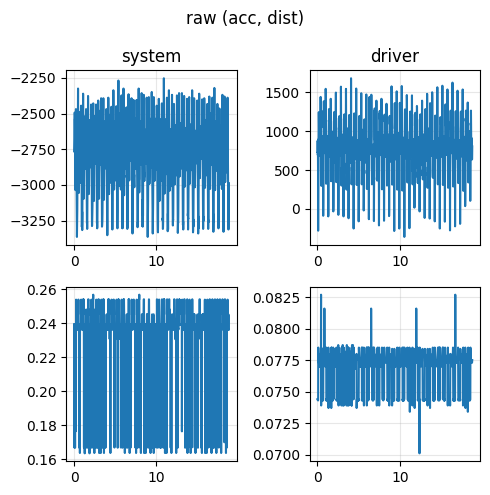

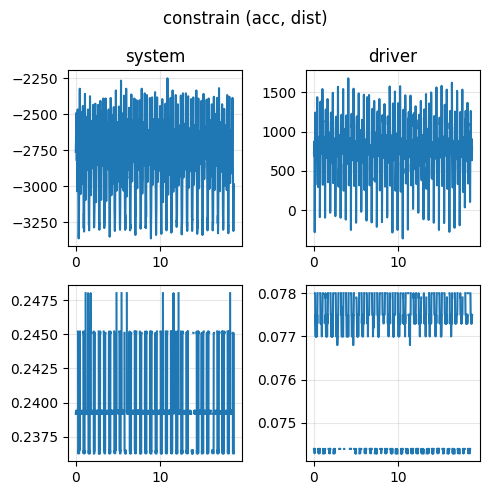

In [370]:
## LOAD, SYNCHRONIZE, AND PARSE DUAL DATASETS
print("Loading raw data...")

parsed_list = []
for i in range(f_s[0]):
    dim1 = []
    for j in range(f_s[1]):
        dim2 = []
        for k in range(f_s[2]):
            file_path = str(fp[i, j, k])
            dim2.append(load_and_parse_data(file_path))
        dim1.append(dim2)
    parsed_list.append(dim1)

raw_dat = np.array(parsed_list, dtype=object)

'''my_subset = raw_data_dataset[0, 0, 1] 
time_data = my_subset[:, 0] # how to access shi
acc_data  = my_subset[:, 2]''' 

for i in range(f_s[0]):
    for j in range(f_s[1]):
        for k in range(f_s[2]):
            print(f"Dataset [{i}, {j}, {k}] shape: {raw_dat[i, j, k].shape}, unique timestamps: {len(set(t for t in raw_dat[i, j, k][:, 5] if t is not False))}")

raw_data1 = raw_dat[0,0,0] #1-highbase
raw_data2 = raw_dat[0,0,1] #2-highbase

'''
dat3_ = load_and_parse_data(dat3) #generated data for testing sin sum
dist3 = dat3_[:, 1].astype(float)
t3 = dat3_[:, 0].astype(float) / 1000.0 

data1=raw_data1[100:700]
data2=raw_data2[100:700]
debug - skip synchronization, splice manually

t1=t1 - t1[0]  # Rebase to zero
t2=t2 - t2[0]  # Rebase to zero
#for now 

quick_plot(acc1_x,(t1-t1[0]))
quick_plot(acc2_x,(t2-t2[0])) #checks
#quick_plot(dist3,t3)
if True:
    fig, axes = plt.subplots(2, 2, figsize=(5, 5))
    
    axes[0, 0].plot(t1, acc1_x, linewidth=1.5)
    axes[0, 0].grid(True, alpha=0.3)
    
    axes[0, 1].plot(t2, acc2_x,linewidth=1.5)
    axes[0, 1].grid(True, alpha=0.3)
    
    axes[1, 0].plot(t1, dist1, linewidth=1.5)
    axes[1, 0].grid(True, alpha=0.3)
    
    axes[1, 1].plot(t2, dist2,linewidth=1.5)
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
'''
def sync_and_make_cols(raw_data1,raw_data2,*args):
    #print("\nSynchronizing datasets...")
    data1, data2 = synchronize_datasets(raw_data1,raw_data2)
    if len(args)==1:
        slic=args[0][0],args[0][0]
    '''
    print(f"Synchronized dat1 shape: {data1.shape}")
    print(f"Synchronized dat2 shape: {data2.shape}")
    print(f"Synchronized time range: {data1[0, 0]:.3f} to {data1[-1, 0]:.3f} ms (dat1)")
    print(f"Synchronized time range: {data2[0, 0]:.3f} to {data2[-1, 0]:.3f} ms (dat2)")
    #use in actual code, not for this sample.
    '''   
    # Extract synchronized data
    # Columns: [millis_sec, dist, acc_x, acc_y, acc_z]
    t1 = data1[:, 0].astype(float) / 1000.0 
    dist1 = data1[:, 1].astype(float) / 100.0  # Column 1: distance (convert to meters)
    acc1_x = data1[:, 2].astype(float)
    #acc1_y = data1[:, 3].astype(float)
    #acc1_z = data1[:, 4].astype(float)

    t2 = data2[:, 0].astype(float) / 1000.0 
    dist2 = data2[:, 1].astype(float) / 100.0  # Column 1: distance (convert to meters)
    acc2_x = data2[:, 2].astype(float)
    #acc2_y = data2[:, 3].astype(float)
    #acc2_z = data2[:, 4].astype(float)
    if args:
        t1, t2 = t1-t1[0], t2-t2[0]
    #print("\nData successfully loaded and synchronized.")
    return t1,dist1,acc1_x,t2,dist2,acc2_x

def make_cols(data1, *args):
    #print("\nSynchronizing datasets...")
    slic = (0, 1)
    if len(args)>0:
        slic = (args[0][0],args[0][1])
    # Columns: [millis_sec, dist, acc_x, acc_y, acc_z]
    t1 = data1[:, 0].astype(float)[:] / 1000.0 
    dist1 = data1[:, 1].astype(float)[:] / 100.0  
    acc1_x = data1[:, 2].astype(float)[:]
    #acc1_y = data1[:, 3].astype(float)
    #acc1_z = data1[:, 4].astype(float)
    t1 = t1-t1[0]
    #print("\nData successfully loaded (unsynced).")
    return t1,dist1,acc1_x

t1,dist1,acc1_x,t2,dist2,acc2_x= sync_and_make_cols(raw_data1,raw_data2)
tit=['system', 'driver']
quick_subplot(
    (t1, (acc1_x)), 
    (t2, (acc2_x)), 
    (t1, (dist1)), 
    (t2, (dist2)), struct=(2,2), sup='raw (acc, dist)', tit=tit)

quick_subplot(
    (t1, constrain(acc1_x,0)), 
    (t2, constrain(acc2_x,0)), 
    (t1, constrain(dist1,10)), 
    (t2, constrain(dist2,10)), struct =(2,2), sup='constrain (acc, dist)', tit=tit)


In [ ]:
## ACCELEROMETER CALIBRATION HELPERS

def output_to_acc(out, coeffs):
    acc = [[], [], []]
    for i in range(3):
        o = out[i]
        acc[i] = np.array(o) * coeffs[i][0] + coeffs[i][1]
    return np.array(acc)

def acc_callib(a, x, visual_1=False, visual_2=False, visual_3=False):
    if a[0] == '' or a[1] == '' or a[2] == '':
        return None, None

    original_data = []
    calib_arr = []
    divisors = [1000, 100, 1, 1, 1]
    '''
    for i, path in enumerate(a):
        raw = np.loadtxt(path, delimiter=',', converters={0: parse_first_field})
        n_rows = raw.shape[0]
        l1 = []
        l2 = []
        for j in range(5):
            k1 = divisors[j]
            k2 = -9.81 if i + 2 == j else 0
            b = raw[:, j][x[i][0]:(n_rows + x[i][1]) % n_rows] / k1
            c = np.full(len(b), k2)
            mask = (b >= np.percentile(b, 2)) & (b <= np.percentile(b, 98))
            b, c = b[mask], c[mask]
            l1.append(b)
            l2.append(c)
        original_data.append(l1)
        calib_arr.append(l2)
    '''
    for i, path in enumerate(a):
        raw = load_and_parse_data(str(path))
        n_rows = raw.shape[0]
        l1 = []
        l2 = []

        start_idx = x[i][0]
        end_idx = (n_rows + x[i][1]) % n_rows
        
        for j in range(5):
            k1 = divisors[j]
            k2 = -9.81 if i + 2 == j else 0.0
            
            b = raw[start_idx:end_idx, j] / k1
            c = np.full(len(b), k2)
            
            p2, p98 = np.percentile(b, 2), np.percentile(b, 98)
            mask = (b >= p2) & (b <= p98)
            
            l1.append(b[mask])
            l2.append(c[mask])     
        original_data.append(l1)
        calib_arr.append(l2)


    s1, s2, s3 = 7, 7, 10

    if visual_1:
        fig, axes = plt.subplots(3, 3, figsize=(s1, s1))
        for i, ax in enumerate(axes.flatten()):
            o = original_data[i//3][i%3 + 2]
            o_1 = calib_arr[i//3][i%3 + 2]
            ax.scatter(np.linspace(0, len(o), len(o)), o, color='blue', s=10, alpha=0.7)
            ax.plot(o_1, color='red', label=f'expected = {o_1[0]}')
            ax.set_title(f'Subplot {i//3} - {acc_name[i%3]}')
            ax.set_xlabel('index')
            ax.legend()
        plt.legend()
        plt.suptitle('Raw values vs Raw expected')
        plt.tight_layout()
        plt.show()

    if visual_2:
        fig, axes = plt.subplots(3, 3, figsize=(s2, s2))
        for i, ax in enumerate(axes.flatten()):
            ax.scatter(original_data[i//3][i%3 + 2], original_data[i//3][i%3 + 2])
            ax.set_title(f"{acc_name[i%3]} calib")
            ax.set_xlabel('output')
            ax.set_ylabel('expected value')
        plt.suptitle('Individual Output-Expected Correspondence')
        plt.tight_layout()
        plt.show()

    output, true_val = [[], [], []], [[], [], []]
    for i in range(3):
        for j in range(3):
            output[i].extend(original_data[i][j+2])
            true_val[i].extend(calib_arr[i][j+2])
    coeffs, covs = [[], [], []], [[], [], []]
    for i in range(3):
        coeffs[i], covs[i] = np.polyfit(output[i], true_val[i], 1, cov=True)
        
    if visual_3:
        fig, axes = plt.subplots(1, 3, figsize=(s3, s3/3), layout='constrained')
        for i, ax in enumerate(axes.flatten()):
            o = output[i]
            o_1 = true_val[i]
            ax.scatter(o, o_1, color='blue', s=10, alpha=0.7)
            ax.plot(o, np.array(o) * coeffs[i][0] + coeffs[i][1], color='red', label=f'best fit {acc_name[i]}')
            ax.set_title(f"{acc_name[i]} calib")
            ax.set_xlabel('output')
            ax.set_ylabel('calibrated value')
            ax.set_box_aspect(1)
            ax.legend()
        plt.suptitle('Output-Expected Correspondence (w best fit)')
        plt.show()
    
    return np.array(coeffs), np.array(covs)

acc_file_paths = (na1,na2)
acc_name = ['x', 'y', 'z']
rang1 = [(20, -100), (60, -20), (40, -20)]
rang2 = [(80, -20), (20, -20), (20, -20)]

cal_coeff1, cal_covs1 = acc_callib(acc_file_paths[0], rang1, 0,0,0)
cal_coeff2, cal_covs2 = acc_callib(acc_file_paths[1], rang2, 0,0,0)

print('Accelerometer calibration coefficients loaded.')


Accelerometer calibration coefficients loaded.


Accelerometer data calibrated.


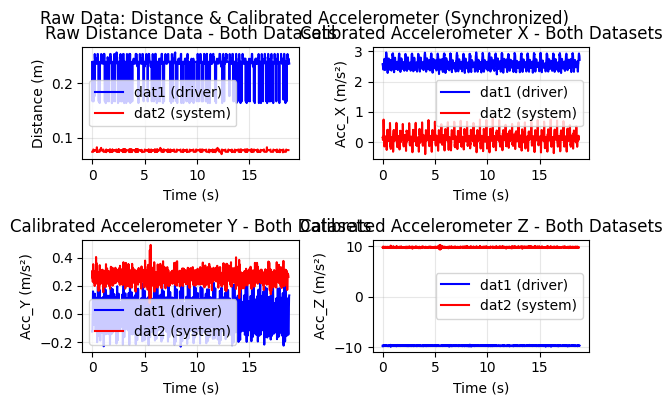

Raw data visualization complete.


In [ ]:
## APPLY CALIBRATION & VISUALIZE RAW DATA (2x2 SUBPLOTS)

# Calibrate accelerometer data using existing coefficients
# acc_calibrated = raw_output * slope + intercept
acc1_calib_x = acc1_x * cal_coeff1[0][0] + cal_coeff1[0][1]
acc1_calib_y = acc1_y * cal_coeff1[1][0] + cal_coeff1[1][1]
acc1_calib_z = acc1_z * cal_coeff1[2][0] + cal_coeff1[2][1]

acc2_calib_x = -1*(+acc2_x * cal_coeff2[0][0] + cal_coeff2[0][1])
acc2_calib_y = -1*(acc2_y * cal_coeff2[1][0] + cal_coeff2[1][1])
acc2_calib_z = -1*(acc2_z * cal_coeff2[2][0] + cal_coeff2[2][1])

print("Accelerometer data calibrated.")

if VIS_RAW:
    fig, axes = plt.subplots(2, 2, figsize=(6, 4))
    
    # Plot 1: Distance data
    axes[0, 0].plot(t1, dist1, 'b-', label='dat1 (driver)', linewidth=1.5)
    axes[0, 0].plot(t2, dist2, 'r-', label='dat2 (system)', linewidth=1.5)
    axes[0, 0].set_xlabel('Time (s)')
    axes[0, 0].set_ylabel('Distance (m)')
    axes[0, 0].set_title('Raw Distance Data - Both Datasets')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Plot 2: Accelerometer X
    axes[0, 1].plot(t1, acc1_calib_x, 'b-', label='dat1 (driver)', linewidth=1.5)
    axes[0, 1].plot(t2, acc2_calib_x, 'r-', label='dat2 (system)', linewidth=1.5)
    axes[0, 1].set_xlabel('Time (s)')
    axes[0, 1].set_ylabel('Acc_X (m/s²)')
    axes[0, 1].set_title('Calibrated Accelerometer X - Both Datasets')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Plot 3: Accelerometer Y
    axes[1, 0].plot(t1, acc1_calib_y, 'b-', label='dat1 (driver)', linewidth=1.5)
    axes[1, 0].plot(t2, acc2_calib_y, 'r-', label='dat2 (system)', linewidth=1.5)
    axes[1, 0].set_xlabel('Time (s)')
    axes[1, 0].set_ylabel('Acc_Y (m/s²)')
    axes[1, 0].set_title('Calibrated Accelerometer Y - Both Datasets')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # Plot 4: Accelerometer Z
    axes[1, 1].plot(t1, acc1_calib_z, 'b-', label='dat1 (driver)', linewidth=1.5)
    axes[1, 1].plot(t2, acc2_calib_z, 'r-', label='dat2 (system)', linewidth=1.5)
    axes[1, 1].set_xlabel('Time (s)')
    axes[1, 1].set_ylabel('Acc_Z (m/s²)')
    axes[1, 1].set_title('Calibrated Accelerometer Z - Both Datasets')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.suptitle('Raw Data: Distance & Calibrated Accelerometer (Synchronized)', y=1.00)
    plt.show()

print("Raw data visualization complete.")



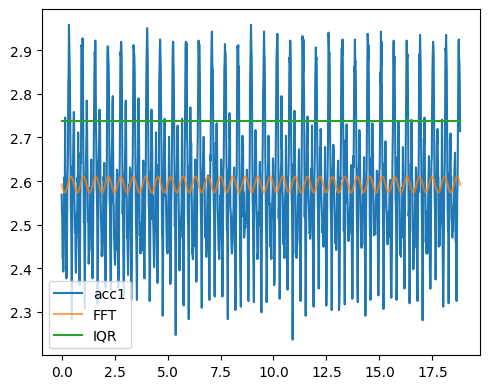

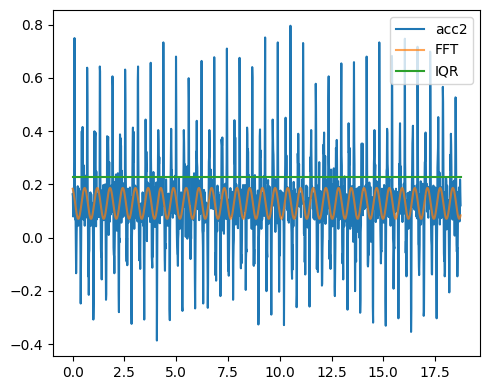

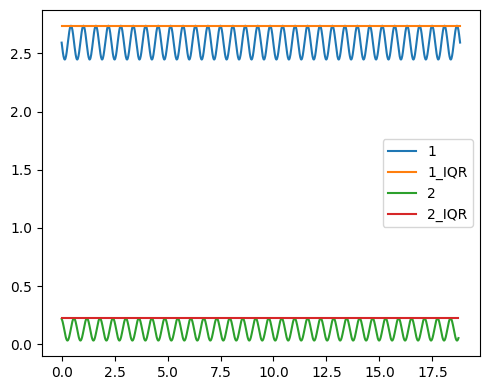

best fit: 0.15 sin(10.69t + -3.14) + 2.59
best fit: 0.10 sin(10.25t + 1.90) + 0.13

Expected frequency: 10.24, 9.05 rad/s
from FFT:-
1) acc: 10.69 ± 0.03 (dat1) | NRMSE = 0.16, NRSE = 0.16
2) acc: 10.25 ± 0.00 (dat2) | NRMSE = 0.16, NRSE = 0.16

FFT del_freq = 1.04 ± 0.00
IQR Amp_Mag = 1.52 ± 0.06


In [ ]:
## Abandoned analysis: Sinusoidal Fitting, FFT, IQR, and Hybrid Analysis
'''dist1, dist2 = constrain(dist1,10), constrain(dist2,10)

params1_dist, cov1_dist = fit_sin(t1, dist1, w_bounds=W_BOUNDS)
params2_dist, cov2_dist = fit_sin(t2, dist2, w_bounds=W_BOUNDS)

print(f"dat1 distance fit params: A={params1_dist[0]:.2f}, w={params1_dist[1]:.2f}, "
      f"phi={params1_dist[2]:.2f}, ofs={params1_dist[3]:.2f}")
print(f"dat2 distance fit params: A={params2_dist[0]:.2f}, w={params2_dist[1]:.2f}, "
      f"phi={params2_dist[2]:.2f}, ofs={params2_dist[3]:.2f}")

quick_syncplot([dist1,sin_fit(t1, *params1_dist)],[t1,t1],'dist1')
quick_syncplot([dist2,sin_fit(t2, *params2_dist)],[t2,t2],'dist2')
'''
#FFT # for frequency detection
params1_acc, cov1_acc = fit_sin(t1, acc1_calib_x, w_bounds=W_BOUNDS)
params2_acc, cov2_acc = fit_sin(t2, acc2_calib_x, w_bounds=W_BOUNDS)

FFT_freq_shift = (params1_acc[1]/params2_acc[1])
# sigma_Mf = Mf * sqrt( (sigma_f1/f1)^2 + (sigma_f2/f2)^2 ) #Magnification
FFT_freq_shift_err = FFT_freq_shift*np.sqrt((cov1_acc[1,1]/params1_acc[1])**2 + (cov2_acc[1,1]/params2_acc[1])**2)

#IQR # for amplitude detection
rang_ofs = 25 # quarter
spr_1 = (np.percentile(acc1_calib_x, 100- 1e-16 -rang_ofs) - np.percentile(acc1_calib_x, 1e-16 + rang_ofs))
spr_2 = (np.percentile(acc2_calib_x, 100- 1e-16 -rang_ofs) - np.percentile(acc2_calib_x, 1e-16 + rang_ofs))
#exluding edge quartiles. due to high acc_noise at low amplitudes. 

IQR_amp_mag = (spr_1 / spr_2 ) #ignore iqr coeff, coz cancels out.

iqr_amp1 = spr_1 / np.sqrt(2)
iqr_amp2 = spr_2 / np.sqrt(2)
s1=np.full(2, iqr_amp1+np.mean(acc1_calib_x)) # turn into arrays to plot
s2=np.full(2, iqr_amp2+np.mean(acc2_calib_x))
t_1 = np.array([t1[0], t1[-1]])
t_2 = np.array([t2[0], t2[-1]])

# IQR Error propogation
# Derived from order statistics + harmonic Probability Density Function (PDF): sigma_A ~ 0.96 * A / sqrt(N)
iqr_amp1_err = 0.9613 * iqr_amp1 / np.sqrt(len(acc1_calib_x))
iqr_amp2_err = 0.9613 * iqr_amp2 / np.sqrt(len(acc2_calib_x))

# sigma_Ma = Ma * sqrt( (sigma_A1/A1)^2 + (sigma_A2/A2)^2 ) #Magnification
# as sigma_A is a fucntion of A (due to harmonics and stuff), (sigma_A/A)^2 = (0.96**2 / N) and A's cancel out.
rel_err_sq = (0.9613**2 / len(acc1_calib_x)) + (0.9613**2 / len(acc2_calib_x))
IQR_amp_mag_err = IQR_amp_mag * np.sqrt(rel_err_sq)

#hybrid params
hyb1 = np.array([iqr_amp1, params1_acc[1], params1_acc[2], params1_acc[3]])
hyb2 = np.array([iqr_amp2, params2_acc[1], params2_acc[2], params2_acc[3]])

quick_syncplot([acc1_calib_x,sin_fit(t1, *params1_acc),s1],[t1,t1,t_1],'acc1','FFT','IQR', alpha=[1.0,0.7,1.0])
quick_syncplot([acc2_calib_x,sin_fit(t2, *params2_acc),s2],[t2,t2,t_2],'acc2','FFT','IQR', alpha=[1.0,0.7,1.0])

quick_syncplot([sin_fit(t1, *hyb1),s1,sin_fit(t2, *hyb2),s2],[t1,t_1,t2,t_2],'1','1_IQR','2', '2_IQR')
alpha=[0.7,0.5,1.0,0.8]

w_expected = w_h,w_l
#best fit combines amplitude from IQR, with other Params from FFT, to be nice-er.
print(f"best fit: {iqr_amp1:.2f} sin({params1_acc[1]:.2f}t + {params1_acc[2]:.2f}) + {params1_acc[3]:.2f}")
print(f"best fit: {iqr_amp2:.2f} sin({params2_acc[1]:.2f}t + {params2_acc[2]:.2f}) + {params2_acc[3]:.2f}\n")

RMSE1 = RMSE_RSE(acc1_calib_x, sin_fit(t1, *params1_acc))
RMSE2 = RMSE_RSE(acc2_calib_x, sin_fit(t2, *params2_acc))

print(f"Expected frequency: {w_h:.2f}, {w_l:.2f} rad/s")
print('from FFT:-')
print(f"1) acc: {params1_acc[1]:.2f} ± {np.sqrt(cov1_acc[1,1]):.2f} (dat1) | NRMSE = {RMSE1[0]:.2f}, NRSE = {RMSE1[1]:.2f}")
print(f"2) acc: {params2_acc[1]:.2f} ± {np.sqrt(cov2_acc[1,1]):.2f} (dat2) | NRMSE = {RMSE2[0]:.2f}, NRSE = {RMSE2[1]:.2f}\n")

'''
print('from IQR analysis:-')
print(f"acc1 Amplitude = {iqr_amp1:.2f} ± {iqr_amp1_err:.2f} m/s^2")
print(f"acc2 Amplitude = {iqr_amp2:.2f} ± {iqr_amp2_err:.2f} m/s^2\n")
print(f'hilber max_mag = {hilbert_amp(acc1_calib_x)[1] / hilbert_amp(acc2_calib_x)[1]:.2f}')
print(f'hilber mean_mag = {hilbert_amp(acc1_calib_x)[2] / hilbert_amp(acc2_calib_x)[2]:.2f}')
'''

print(f'FFT del_freq = {FFT_freq_shift:.2f} ± {FFT_freq_shift_err:.2f}')
print(f'IQR Amp_Mag = {IQR_amp_mag:.2f} ± {IQR_amp_mag_err:.2f}')

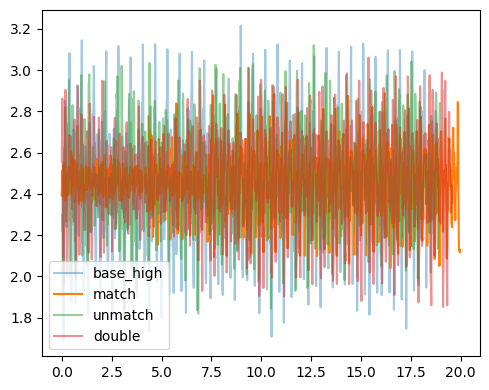

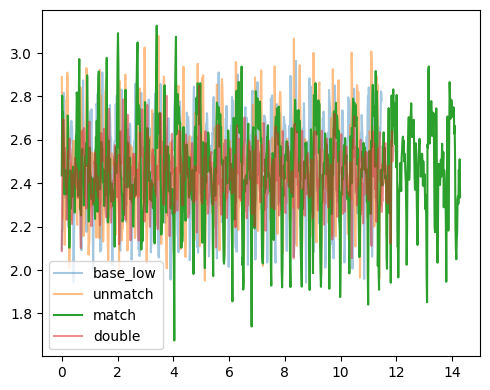

Relative Acceleration (Flexion of structure)
base    | Driver-High: 0.251 m/s^2 | Driver-Low: 0.145 m/s^2
high    | Driver-High: 0.136 m/s^2 | Driver-Low: 0.147 m/s^2
low     | Driver-High: 0.217 m/s^2 | Driver-Low: 0.137 m/s^2
double  | Driver-High: 0.212 m/s^2 | Driver-Low: 0.082 m/s^2


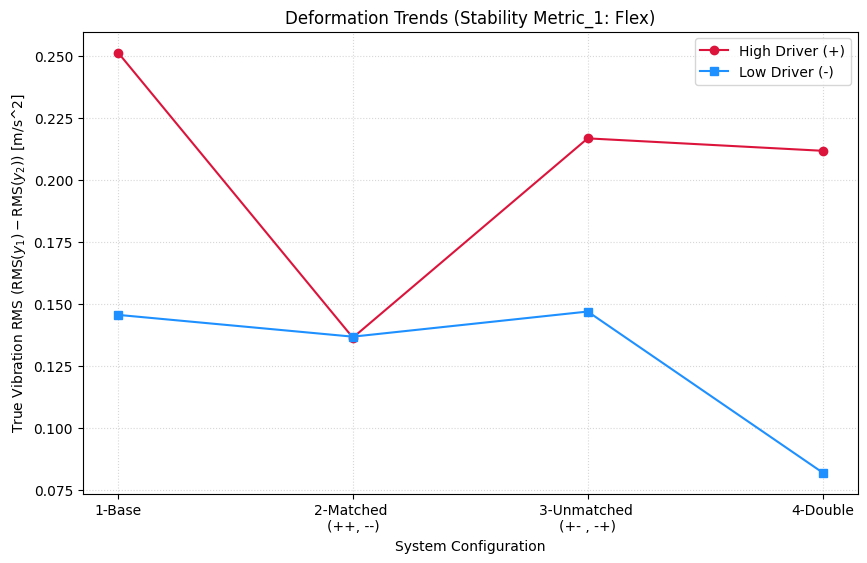

Result A1) It's evident that the matched cases have dips in Relative acceleration compared to the unmatched ones (higher flex_stability).
Result A2) The dip in the matched case is mmuch higher with the high driver. i.e. matched resonators stabilise higher frequencies better.
Result A3) The double resonators also stabilise_flexion better than base case, however the stabilisation of the lower freq_driver is much better.


In [ ]:
def analysis_1():       ## Stability Metric_1: Flex
    t, dist, acc = [],[],[]
    a,b,c =[],[],[]
    for i in range(2):
        for j in range(4):    
            #print([j,i,0],fp[j,i,0],fp[j,i,1]) 
            a_1,b_1,c1,a2,b2,c2=sync_and_make_cols(raw_dat[j,i,0],raw_dat[j,i,1]) # system and driver
            a.append(a_1)
            #b2,c2 = constrain(b2,5),constrain(c2,5)
            b2_alligned, c2_alligned = np.interp(a_1, a2, b2), np.interp(a_1, a2, c2)
            b.append(b_1-b2_alligned)
            c.append((c1* cal_coeff1[0][0] + cal_coeff1[0][1])+(c2_alligned* cal_coeff2[0][0] + cal_coeff2[0][1])) #calibrate inverse of calcoeff_2
        t.append(a)
        dist.append(b)
        acc.append(c)
        a,b,c =[],[],[]


    def RMS(x):
        return np.sqrt(np.mean((np.nan_to_num(x)))**2)
        #return np.sqrt(np.mean((np.nan_to_num(x) - 0.375))**2))
    '''
    def RMS(x):
        clean_x = np.nan_to_num(x)
        zero_centered = clean_x - np.mean(clean_x)
        return np.sqrt(np.mean(zero_centered**2))

    k12=[1,10]
    #relative accleration plots
    quick_syncplot([acc[0][0],constrain(acc[0][1],k12[0]),acc[0][2],acc[0][3]],[t[0][0],t[0][1],t[0][2],t[0][3]],'base_high','match','unmatch','double', alpha=[0.4,1.0,0.5,0.5,1.0])
    quick_syncplot([acc[1][0],acc[1][1],acc[1][2],acc[1][3]],[t[1][0],t[1][1],t[1][2],t[1][3]],'base_low','unmatch','match','double', alpha=[0.4,0.5,1.0,0.5])


    nam1=['high','low']
    nam2=['base','high','low','double']

    def constrain_drop(data,ofs):
        lower_bound=np.percentile(data,1e-16 +ofs)
        upper_bound=np.percentile(data,100 -1e-16 -ofs)
        filtered_data = data[(data >= lower_bound) & (data <= upper_bound)]
        return filtered_data

    l=[[],[]]
    for i in range(2):
        k11=1
        for j in range(4):
            if j==3:
                k11=1.00
            out=RMS(constrain_drop(k11*acc[i][j],k12[i]))
            l[i].append(out)
            #print(f'{nam1[i]}-{nam2[j]}: {out:.4f}')
    '''
    plt.plot(l[0],label='high')
    plt.plot(l[1],label='low')
    plt.legend()
    plt.show()
    '''
    high_plot = l[0]

    # Flip indices 1 and 2 for the low series to match the x-axis layout
    low_plot = [l[1][0], l[1][2], l[1][1], l[1][3]] 

    print("="*60)
    print("Relative Acceleration (Flexion of structure)")
    print("="*60)
    for k in range(4):
        print(f"{nam2[k]:<7} | Driver-High: {l[0][k]:.3f} m/s^2 | Driver-Low: {l[1][k]:.3f} m/s^2")

    plt.figure(figsize=(10, 6))
    x_labels = ['1-Base', '2-Matched \n(++, --)', '3-Unmatched \n(+- , -+)', '4-Double']
    plt.plot(high_plot, label='High Driver (+)', marker='o', color='crimson')
    plt.plot(low_plot, label='Low Driver (-)', marker='s', color='dodgerblue')

    plt.xticks(range(4), x_labels)
    plt.xlabel('System Configuration')
    plt.ylabel(r'True Vibration RMS ($\text{RMS}(y_1) - \text{RMS}(y_2)$) [m/s^2]')
    plt.title('Deformation Trends (Stability Metric_1: Flex)')
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.5)
    plt.show()

    print("Result A1) It's evident that the matched cases have dips in Relative acceleration compared to the unmatched ones (higher flex_stability).")
    print("Result A2) The dip in the matched case is mmuch higher with the high driver. i.e. matched resonators stabilise higher frequencies better.")
    print("Result A3) The double resonators also stabilise_flexion better than base case, however the stabilisation of the lower freq_driver is much better.")

analysis_1()

Base High       | Shift: 1.01 ± 0.00
Base Low        | Shift: 0.94 ± 0.00
Matched High    | Shift: 0.99 ± 0.00
Matched Low     | Shift: 1.25 ± 0.01
Unmatched High  | Shift: 1.00 ± 0.00
Unmatched Low   | Shift: 0.99 ± 0.00
Double High     | Shift: 1.00 ± 0.00
Double Low      | Shift: 1.07 ± 0.00


<>:76: SyntaxWarning: invalid escape sequence '\o'
<>:76: SyntaxWarning: invalid escape sequence '\o'
/var/folders/yz/n114wfl97g9g4tbp489zvmkc0000gn/T/ipykernel_1218/888422332.py:76: SyntaxWarning: invalid escape sequence '\o'
  plt.ylabel('Frequency Shift Ratio ($\omega_1 / \omega_2$)', fontsize=11, labelpad=10)


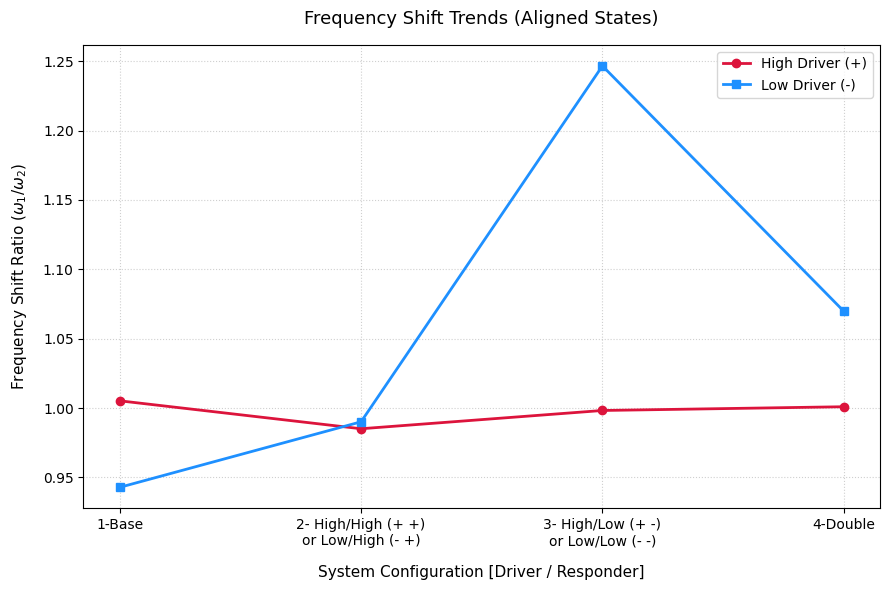

10.22±0.00 rad/s


In [ ]:
### USELESS, DO NOT USE (extra code)
# Explicitly separate Setup 1 and Setup 2
t0 = [[], []]  # t0[0] = Setup 1 datasets, t0[1] = Setup 2 datasets
ac = [[], []]  # ac[0] = Setup 1 datasets, ac[1] = Setup 2 datasets

# Process by Setup first (i1), then Case (j), then State (i)
for i1 in range(2):      # 0: Setup 1, 1: Setup 2
    for j in range(4):   # 0: Base, 1: Matched, 2: Unmatched, 3: Double
        for i in range(2): # 0: High, 1: Low
            #print(f" Setup {i1+1}, Case {j}, Driver Freq {i}: {fp[j, i, i1]}")
            m_1, n_1, r_1 = make_cols(raw_dat[j, i, i1])
            t0[i1].append(m_1)
            if i1 == 1:
                ac[i1].append(r_1 * cal_coeff1[0][0] + cal_coeff1[0][1])
            else:
                ac[i1].append(-(r_1 * cal_coeff2[0][0] + cal_coeff2[0][1]))

w_0 = [[], []]
w_err = [[], []]

# 8 files per setup
for setup_idx in range(2):
    for k in range(8):
        m_1, m_2 = fit_sin(t0[setup_idx][k], ac[setup_idx][k], w_bounds=W_BOUNDS)
        freq = m_1[1]
        err = np.sqrt(m_2[1,1])
        w_0[setup_idx].append(freq)
        w_err[setup_idx].append(err)

high_shifts = []
low_shifts = []

# k=0: Base High, k=1: Base Low, k=2: Matched High, k=3: Matched Low...
labels = [
    "Base High", "Base Low", 
    "Matched High", "Matched Low", 
    "Unmatched High", "Unmatched Low", 
    "Double High", "Double Low"
]

raw_shifts = []

for k in range(8):
    w1, w2 = w_0[0][k], w_0[1][k]
    w1_err, w2_err = w_err[0][k], w_err[1][k]
    
    freq_shift = w1 / w2
    #error_prop
    freq_shift_err = freq_shift * np.sqrt((w1_err / w1)**2 + (w2_err / w2)**2)
    
    print(f"{labels[k]:<15} | Shift: {freq_shift:.2f} ± {freq_shift_err:.2f}")
    raw_shifts.append(freq_shift)

# Extract High Driver Series (order: Base, Matched/High, Unmatched/Low, Double)
# Indices match: 0 (Base H), 2 (Matched H), 4 (Unmatched H), 6 (Double H)
high_shifts = [raw_shifts[0], raw_shifts[2], raw_shifts[4], raw_shifts[6]]

# Extract Low Driver Series and FLIP the middle two points
# Target order  : Base L, Unmatched L (High), Matched L (Low), Double L
low_shifts = [raw_shifts[1], raw_shifts[5], raw_shifts[3], raw_shifts[7]]

x_positions = [1, 2, 3, 4]
x_labels = [
    '1-Base', 
    '2- High/High (+ +)\nor Low/High (- +)', 
    '3- High/Low (+ -)\nor Low/Low (- -)', 
    '4-Double'
]

plt.figure(figsize=(9, 6))
plt.plot(x_positions, high_shifts, marker='o', linewidth=2, color='crimson', label='High Driver (+)')
plt.plot(x_positions, low_shifts, marker='s', linewidth=2, color='dodgerblue', label='Low Driver (-)')

plt.xticks(x_positions, x_labels)
plt.xlabel('System Configuration [Driver / Responder]', fontsize=11, labelpad=12)
plt.ylabel('Frequency Shift Ratio ($\omega_1 / \omega_2$)', fontsize=11, labelpad=10)
plt.title('Frequency Shift Trends (Aligned States)', fontsize=13, pad=15)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(frameon=True)
plt.tight_layout()
plt.show()

    

'''
t0, d, ac = [],[],[]
m,n,r =[],[],[]
for i in range(2):
    for j in range(4):
        for i1 in range(2):   
            print([j,i,i1],fp[j,i,i1]) 
            m_1,n_1,r_1=make_cols(raw_dat[j,i,i1])
            m.append(m_1)
            n.append(n_1)
            if i1==1:
                r.append((r_1* cal_coeff1[0][0] + cal_coeff1[0][1]))
            else:
                r.append(-(r_1* cal_coeff2[0][0] + cal_coeff2[0][1]))#calibrate inverse of calcoeff_2
    t0.append(m)
    d.append(n)
    ac.append(r)
    m,n,r =[],[],[]

for i in range(2):
    w1 = w_0[i][0]
    w2 = w_0[i][1]
    w1_err = w_err[i][0]
    w2_err = w_err[i][1]
    
    freq_shift = w1 / w2
    
    # Standard error propagation formula
    freq_shift_err = freq_shift * np.sqrt((w1_err / w1)**2 + (w2_err / w2)**2)
    
    print(f"Condition {nam1[i//4]}-{nam2[i%4]} Shift: {freq_shift:.2f} ± {freq_shift_err:.2f}")
'''
'''
slic = (0,-1)
t, dist, acc_calib_x = [],[],[]
a,b,c =[],[],[]

for i in range(2):
    for j in range(4):
        a1,b1,c1 = make_cols(raw_dat[j,0,i])
        a.append(a1)
        b.append(b1)
        c.append(c1* cal_coeff1[0][0] + cal_coeff1[0][1]) #calibrated (ESP 1 - system)
    t.append(a)
    dist.append(b)
    acc_calib_x.append(c)
    a,b,c =[],[],[]



#quick_syncplot([acc_calib_x[0][0],acc_calib_x[0][1],acc_calib_x[0][2],],[t[0][0],t[0][1],t[0][2]],'base_high','match','unmatch', alpha=[1.0,1.0,0.5])
#quick_syncplot([acc_calib_x[1][0],acc_calib_x[1][1],acc_calib_x[1][2],],[t[1][0],t[1][1],t[1][2]],'base_low','unmatch','match', alpha=[1.0,0.5,1.0])

quick_syncplot([acc_calib_x[0][1],acc_calib_x[0][2],acc_calib_x[0][3]],[t[0][1],t[0][2],t[0][3]],'match_high','unmatch','double', alpha=[1.0,0.5,0.7])
quick_syncplot([acc_calib_x[1][1],acc_calib_x[1][2],acc_calib_x[1][3]],[t[1][1],t[1][2],t[1][3]],'unmatch','match_low','double', alpha=[0.5,1.0,0.7])



nam1=['high','low']
nam2=['base','high','low','double']

for i in range(2):
    for j in range(4):
        print(f'{nam1[i]}-{nam2[j]}: {RMS(constrain(acc_calib_x[i][j],2)):.4f}')

'''

#t11,dist11,acc11_x = make_cols(raw_dat[0,0,0])
#t21,dist21,acc21_x = make_cols(raw_dat[1,0,0])
#[2,0,0] unmatched high

#acc21_calib_x = acc21_x * cal_coeff2[0][0] + cal_coeff2[0][1]

#quick_syncplot([acc11_calib_x],[t11],'acc1', alpha=[1.0,0.7,1.0])
#quick_syncplot([acc21_calib_x],[t21],'acc2', alpha=[1.0,0.7,1.0])
#quick_syncplot([acc11_calib_x,acc21_calib_x,],[t11,t21],'base_high','matched_high')

'''
#FFT # for frequency detection
params11_acc, cov11_acc = fit_sin(t11, acc11_calib_x, w_bounds=W_BOUNDS)
params21_acc, cov21_acc = fit_sin(t21, acc21_calib_x, w_bounds=W_BOUNDS)

FFT_freq_shift1 = (params11_acc[1]/params21_acc[1])
# sigma_Mf = Mf * sqrt( (sigma_f1/f1)^2 + (sigma_f2/f2)^2 ) #Magnification
FFT_freq_shift_err1 = FFT_freq_shift1*np.sqrt((cov1_acc[1,1]/params11_acc[1])**2 + (cov2_acc[1,1]/params21_acc[1])**2)

#IQR # for amplitude detection
rang_ofs = 25 # quarter
spr_11 = (np.percentile(acc11_calib_x, 100- 1e-16 -rang_ofs) - np.percentile(acc11_calib_x, 1e-16 + rang_ofs))
spr_21 = (np.percentile(acc21_calib_x, 100- 1e-16 -rang_ofs) - np.percentile(acc21_calib_x, 1e-16 + rang_ofs))
#exluding edge quartiles. due to high acc_noise at low amplitudes. 

IQR_amp_mag1 = (spr_11 / spr_21 ) #ignore iqr coeff, coz cancels out.

iqr_amp11 = spr_11 / np.sqrt(2)
iqr_amp21 = spr_21 / np.sqrt(2)
s11=np.full(2, iqr_amp11+np.mean(acc11_calib_x)) # turn into arrays to plot
s21=np.full(2, iqr_amp21+np.mean(acc21_calib_x))
t_11 = np.array([t11[0], t11[-1]])
t_21 = np.array([t21[0], t21[-1]])

# IQR Error propogation
# Derived from order statistics + harmonic Probability Density Function (PDF): sigma_A ~ 0.96 * A / sqrt(N)
iqr_amp11_err = 0.9613 * iqr_amp11 / np.sqrt(len(acc11_calib_x))
iqr_amp21_err = 0.9613 * iqr_amp21 / np.sqrt(len(acc21_calib_x))

# sigma_Ma = Ma * sqrt( (sigma_A1/A1)^2 + (sigma_A2/A2)^2 ) #Magnification
# as sigma_A is a fucntion of A (due to harmonics and stuff), (sigma_A/A)^2 = (0.96**2 / N) and A's cancel out.
rel_err_sq1 = (0.9613**2 / len(acc11_calib_x)) + (0.9613**2 / len(acc21_calib_x))
IQR_amp_mag_err1 = IQR_amp_mag1 * np.sqrt(rel_err_sq1)

#hybrid params
hyb11 = np.array([iqr_amp11, params11_acc[1], params11_acc[2], params11_acc[3]])
hyb21 = np.array([iqr_amp21, params21_acc[1], params21_acc[2], params21_acc[3]])

quick_syncplot([acc11_calib_x,sin_fit(t11, *params11_acc),s11],[t11,t11,t_11],'acc1','FFT','IQR', alpha=[1.0,0.7,1.0])
quick_syncplot([acc21_calib_x,sin_fit(t21, *params21_acc),s21],[t21,t21,t_21],'acc2','FFT','IQR', alpha=[1.0,0.7,1.0])

quick_syncplot([sin_fit(t11, *hyb11),s11,sin_fit(t21, *hyb21),s21],[t11,t_11,t21,t_21],'1','1_IQR','2', '2_IQR')
alpha=[0.7,0.5,1.0,0.8]

w_expected = w_h,w_l
#best fit combines amplitude from IQR, with other Params from FFT, to be nice-er.
print(f"best fit: {iqr_amp11:.2f} sin({params11_acc[1]:.2f}t + {params11_acc[2]:.2f}) + {params11_acc[3]:.2f}")
print(f"best fit: {iqr_amp21:.2f} sin({params21_acc[1]:.2f}t + {params21_acc[2]:.2f}) + {params21_acc[3]:.2f}\n")

RMSE1 = RMSE_RSE(acc11_calib_x, sin_fit(t11, *params11_acc))
RMSE2 = RMSE_RSE(acc21_calib_x, sin_fit(t21, *params21_acc))

print(f"Expected frequency: {w_h:.2f}, {w_l:.2f} rad/s")
print('from FFT:-')
print(f"1) acc: {params11_acc[1]:.2f} ± {np.sqrt(cov1_acc[1,1]):.2f} (dat1) | NRMSE = {RMSE1[0]:.2f}, NRSE = {RMSE1[1]:.2f}")
print(f"2) acc: {params21_acc[1]:.2f} ± {np.sqrt(cov2_acc[1,1]):.2f} (dat2) | NRMSE = {RMSE2[0]:.2f}, NRSE = {RMSE2[1]:.2f}\n")

print('from IQR analysis:-')
print(f"acc1 Amplitude = {iqr_amp11:.2f} ± {iqr_amp11_err:.2f} m")
print(f"acc2 Amplitude = {iqr_amp21:.2f} ± {iqr_amp21_err:.2f} m\n")
'''
#print(f'hilber max_mag = {hilbert_amp(acc11_calib_x)[1] / hilbert_amp(acc21_calib_x)[1]:.2f}')
#print(f'hilber mean_mag = {hilbert_amp(acc11_calib_x)[2] / hilbert_amp(acc21_calib_x)[2]:.2f}')
'''
print(f'FFT del_freq = {FFT_freq_shift1:.2f} ± {FFT_freq_shift_err1:.2f}')
print(f'IQR Amp_Mag = {IQR_amp_mag1:.2f} ± {IQR_amp_mag_err1:.2f}')
'''

a_11=2
params11_acc, cov11_acc = fit_sin(t[0][a_11], acc[0][a_11], w_bounds=W_BOUNDS)
x11=sin_fit(t[0][a_11], *params11_acc)
print(f'{params11_acc[1]:.2f}±{cov11_acc[1,1]:.2f} rad/s')

#FFT # for frequency detection
#params11_acc, cov11_acc = fit_sin(t[0][0], acc[0][0], w_bounds=W_BOUNDS)
#params21_acc, cov11_acc = fit_sin(t[1][0], acc[1][0], w_bounds=W_BOUNDS)
#FFT_freq_shift1 = (params11_acc[1]/params21_acc[1])
## sigma_Mf = Mf * sqrt( (sigma_f1/f1)^2 + (sigma_f2/f2)^2 ) #Magnification
#FFT_freq_shift_err1 = FFT_freq_shift1*np.sqrt((cov1_acc[1,1]/params11_acc[1])**2 + (cov2_acc[1,1]/params21_acc[1])**2)
#print(f'{FFT_freq_shift_err1:.2f} ± {FFT_freq_shift1:.2f}')

RMS RATIO ANALYSIS: RMS(System) / RMS(Driver)
Base High       | Sys RMS: 11.529 | Drv RMS (Cal): 2.214 | Ratio: 5.208
Base Low        | Sys RMS: 9.347 | Drv RMS (Cal): 2.217 | Ratio: 4.216
Matched High    | Sys RMS: 12.178 | Drv RMS (Cal): 2.215 | Ratio: 5.499
Matched Low     | Sys RMS: 8.056 | Drv RMS (Cal): 2.209 | Ratio: 3.648
Unmatched High  | Sys RMS: 10.940 | Drv RMS (Cal): 2.211 | Ratio: 4.947
Unmatched Low   | Sys RMS: 10.444 | Drv RMS (Cal): 2.227 | Ratio: 4.689
Double High     | Sys RMS: 14.543 | Drv RMS (Cal): 2.141 | Ratio: 6.793
Double Low      | Sys RMS: 11.051 | Drv RMS (Cal): 2.188 | Ratio: 5.050


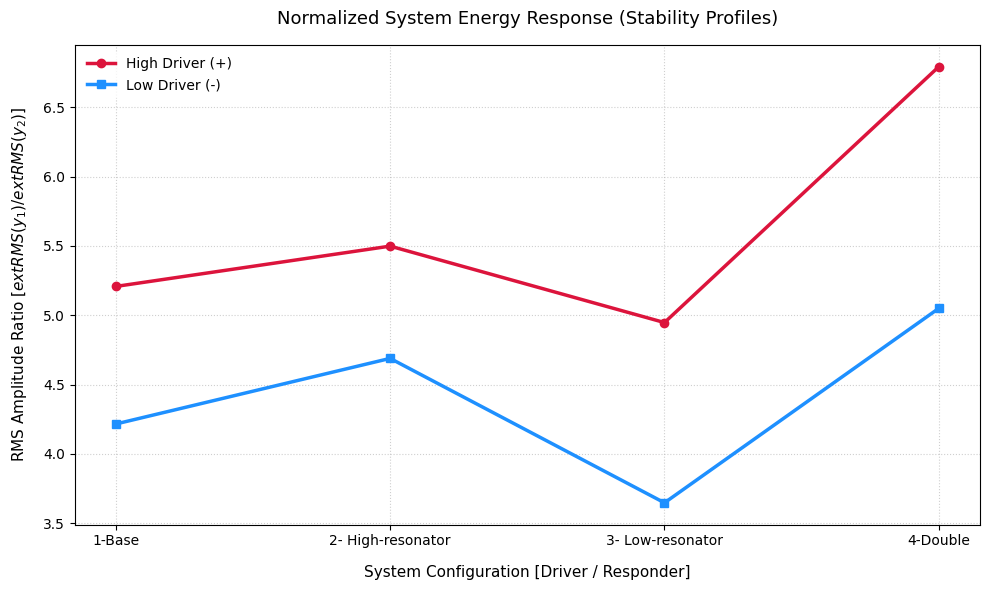

In [ ]:
## repeat tranmission matching graph.

raw_rms_ratios = []
labels = [
    "Base High", "Base Low", 
    "Matched High", "Matched Low", 
    "Unmatched High", "Unmatched Low", 
    "Double High", "Double Low"
]

print("RMS RATIO ANALYSIS: RMS(System) / RMS(Driver)")

flat_idx = 0
for j in range(4):     # 0: Base, 1: Matched, 2: Unmatched, 3: Double
    for i in range(2): # 0: High, 1: Low
        
        # FIXED: Read directly from your pre-calibrated arrays for Setup 1 (index 0)
        # Based on your make_cols unpacking order:
        # t0[0][flat_idx] corresponds to your system_acc (m_1)
        # ac[0][flat_idx] corresponds to your calibrated driver_acc (calibrated r_1)
        system_acc = t0[0][flat_idx]
        driver_acc = ac[0][flat_idx]
        
        # Calculate individual Calibrated Root Mean Squares
        rms_system = np.sqrt(np.mean(system_acc**2))
        rms_driver = np.sqrt(np.mean(driver_acc**2))
        
        # Handle division safety
        if rms_driver == 0:
            ratio = np.nan
        else:
            ratio = rms_system / rms_driver
            
        raw_rms_ratios.append(ratio)
        
        print(f"{labels[flat_idx]:<15} | Sys RMS: {rms_system:.3f} | Drv RMS (Cal): {rms_driver:.3f} | Ratio: {ratio:.3f}")
        
        flat_idx += 1 # Advance sequence pointer



# --- 2. Extract and Align the High & Low Series ---
# High Driver Series (Order: Base, Matched/High, Unmatched/Low, Double)
# Flat indices: 0 (Base H), 2 (Matched H), 4 (Unmatched H), 6 (Double H)
high_rms = [raw_rms_ratios[0], raw_rms_ratios[2], raw_rms_ratios[4], raw_rms_ratios[6]]

# Low Driver Series (Flip middle elements to align states to [Base, -+, --, Double])
# Flat indices: 1 (Base L), 5 (Unmatched L/High), 3 (Matched L/Low), 7 (Double L)
low_rms = [raw_rms_ratios[1], raw_rms_ratios[5], raw_rms_ratios[3], raw_rms_ratios[7]]


# --- 3. Plot Normalized RMS Trends ---
x_positions = [1, 2, 3, 4]
x_labels = [
    '1-Base', 
    '2- High-resonator', 
    '3- Low-resonator', 
    '4-Double'
]

plt.figure(figsize=(10, 6))

# Plot both normalized lines
plt.plot(x_positions, high_rms, marker='o', linewidth=2.5, color='crimson', label='High Driver (+)')
plt.plot(x_positions, low_rms, marker='s', linewidth=2.5, color='dodgerblue', label='Low Driver (-)')

# Graph formatting adjustments
plt.xticks(x_positions, x_labels)
plt.xlabel('System Configuration [Driver / Responder]', fontsize=11, labelpad=12)
plt.ylabel('RMS Amplitude Ratio [$\text{RMS}(y_1) / \text{RMS}(y_2)$]', fontsize=11, labelpad=10)
plt.title('Normalized System Energy Response (Stability Profiles)', fontsize=13, pad=15)

# Ensure the y-axis dynamically shows true variation scaling, or force 0 baseline if preferred
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(frameon=True, facecolor='white', edgecolor='none')
plt.tight_layout()

# Render graph
plt.show()


 RMS(System) | RMS(Driver) [raw values]
Base High       | Sys RMS: 11.529 m/s^2 | Drv RMS (Cal): 2.214 m/s^2
Base Low        | Sys RMS: 9.347 m/s^2 | Drv RMS (Cal): 2.217 m/s^2
Matched High    | Sys RMS: 12.178 m/s^2 | Drv RMS (Cal): 2.215 m/s^2
Matched Low     | Sys RMS: 8.056 m/s^2 | Drv RMS (Cal): 2.209 m/s^2
Unmatched High  | Sys RMS: 10.940 m/s^2 | Drv RMS (Cal): 2.211 m/s^2
Unmatched Low   | Sys RMS: 10.444 m/s^2 | Drv RMS (Cal): 2.227 m/s^2
Double High     | Sys RMS: 14.543 m/s^2 | Drv RMS (Cal): 2.141 m/s^2
Double Low      | Sys RMS: 11.051 m/s^2 | Drv RMS (Cal): 2.188 m/s^2


RMS magnification ratio (RMS(y_1) / RMS(y_2)) [tranmission]
1-Base             | Driver-High: 5.208 | Driver-Low: 4.216
2-Resonator-High   | Driver-High: 5.499 | Driver-Low: 4.689
3-Resonator-Low    | Driver-High: 4.947 | Driver-Low: 3.648
4-Double           | Driver-High: 6.793 | Driver-Low: 5.050


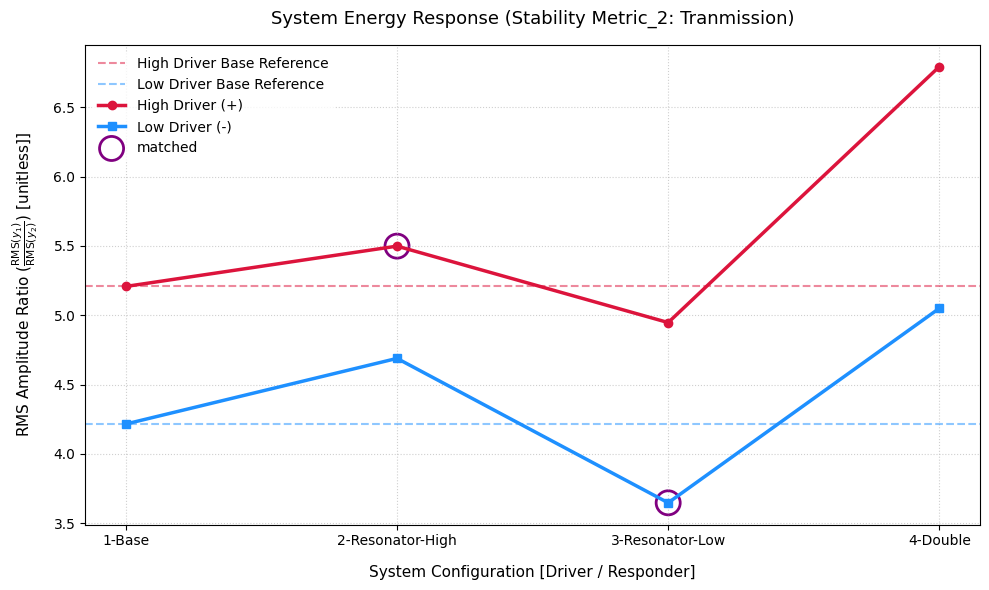

Relative Transmission (Residual Delta from Base case)
1-Base             | Driver-High: 0.000 | Driver-Low: 0.000
2-Resonator-High   | Driver-High: 0.291 | Driver-Low: 0.473
3-Resonator-Low    | Driver-High: -0.260 | Driver-Low: -0.568
4-Double           | Driver-High: 1.585 | Driver-Low: 0.834


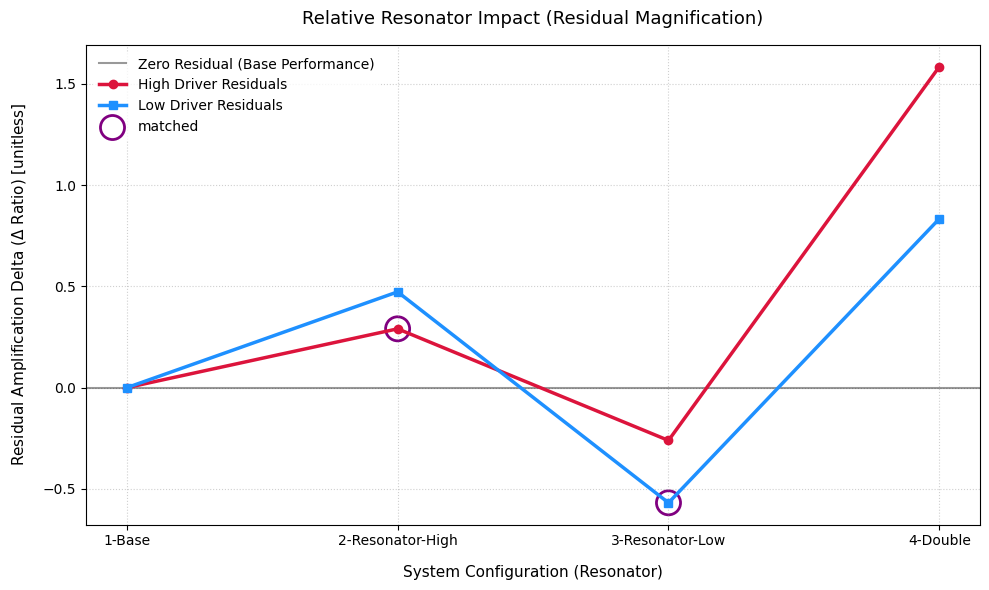

Result B1) It's evident that the matched cases have dips in Energy compared to the unmatched ones (higher transmission_stability).
Result B2) Both double resonant systems cause a large increase in energy transmission. This peak is relatively higher for the high-driver. 
It is likely due to a harmonic mode created between the resonators.

NOTE: The reason the base case RMS are different for high and low drivers, is because despite having the same amplitude, the acceleration wave form's ampitude is= Aw^2. 
Therefore the higher driver has more base energy/acceleration.


In [ ]:
def analysis_2():       ##Stability Metric_2: Tranmission
    t0 = [[], []]  # t0[0] = Setup 1 datasets, t0[1] = Setup 2 datasets
    ac = [[], []]  # ac[0] = Setup 1 datasets, ac[1] = Setup 2 datasets

    # Process by Setup first (i1), then Case (j), then State (i)
    for i1 in range(2):      # 0: Setup 1, 1: Setup 2
        for j in range(4):   # 0: Base, 1: Matched, 2: Unmatched, 3: Double
            for i in range(2): # 0: High, 1: Low
                #print(f" Setup {i1+1}, Case {j}, Driver Freq {i}: {fp[j, i, i1]}")
                m_1, n_1, r_1 = make_cols(raw_dat[j, i, i1])
                t0[i1].append(m_1)
                if i1 == 1:
                    ac[i1].append(r_1 * cal_coeff1[0][0] + cal_coeff1[0][1])
                else:
                    ac[i1].append(-(r_1 * cal_coeff2[0][0] + cal_coeff2[0][1]))

    w_0 = [[], []]
    w_err = [[], []]

    # 8 files per setup
    for setup_idx in range(2):
        for k in range(8):
            m_1, m_2 = fit_sin(t0[setup_idx][k], ac[setup_idx][k], w_bounds=W_BOUNDS)
            freq = m_1[1]
            err = np.sqrt(m_2[1,1])
            w_0[setup_idx].append(freq)
            w_err[setup_idx].append(err)

    print("="*60)
    print(" RMS(System) | RMS(Driver) [raw values]")
    print("="*60)
    raw_rms_ratios=[]
    flat_idx = 0
    for j in range(4):     # 0: Base, 1: Matched, 2: Unmatched, 3: Double
        for i in range(2): # 0: High, 1: Low
            # FIXED: Read directly from your pre-calibrated arrays for Setup 1 (index 0)
            # Based on your make_cols unpacking order:
            # t0[0][flat_idx] corresponds to your system_acc (m_1)
            # ac[0][flat_idx] corresponds to your calibrated driver_acc (calibrated r_1)
            system_acc = t0[0][flat_idx]
            driver_acc = ac[0][flat_idx]
            
            # Calculate individual Calibrated Root Mean Squares
            rms_system = np.sqrt(np.mean(system_acc**2))
            rms_driver = np.sqrt(np.mean(driver_acc**2))
            
            # Handle division safety
            if rms_driver == 0:
                ratio = np.nan
            else:
                ratio = rms_system / rms_driver
                
            raw_rms_ratios.append(ratio)
            
            print(f"{labels[flat_idx]:<15} | Sys RMS: {rms_system:.3f} m/s^2 | Drv RMS (Cal): {rms_driver:.3f} m/s^2")
            
            flat_idx += 1 # Advance sequence pointer

    print('\n')

    # --- 1. Your Aligned Series Data ---
    # High Driver Series (Order: Base, High-Resonator, Low-Resonator, Double)
    # indices: 0 (Base H), 2 (Matched H), 4 (Unmatched H), 6 (Double H)
    high_rms = [raw_rms_ratios[0], raw_rms_ratios[2], raw_rms_ratios[4], raw_rms_ratios[6]]

    # Low Driver Series (Aligned to match x-axis order: Base, High-Resonator, Low-Resonator, Double)
    # indices: 1 (Base L), 5 (Unmatched L/High), 3 (Matched L/Low), 7 (Double L)
    low_rms = [raw_rms_ratios[1], raw_rms_ratios[5], raw_rms_ratios[3], raw_rms_ratios[7]]

    x_positions = [1, 2, 3, 4]
    x_labels = [
        '1-Base', 
        '2-Resonator-High', 
        '3-Resonator-Low', 
        '4-Double'
    ]

    print("="*60)
    print("RMS magnification ratio (RMS(y_1) / RMS(y_2)) [tranmission]")
    print("="*60)
    for k in range(4):
        print(f"{x_labels[k]:<18} | Driver-High: {high_rms[k]:.3f} | Driver-Low: {low_rms[k]:.3f}")

    # --- 2. Plotting the Normalized RMS Trends with Base Reference Lines ---
    plt.figure(figsize=(10, 6))

    # Extract baseline thresholds (the 1-Base values)
    base_threshold_high = high_rms[0]
    base_threshold_low = low_rms[0]

    # Add color-matched baseline references with 0.5 transparency (alpha)
    plt.axhline(base_threshold_high, color='crimson', linestyle='--', alpha=0.5, 
                linewidth=1.5, label='High Driver Base Reference')
    plt.axhline(base_threshold_low, color='dodgerblue', linestyle='--', alpha=0.5, 
                linewidth=1.5, label='Low Driver Base Reference')

    # Plot normalized trend lines
    plt.plot(x_positions, high_rms, marker='o', linewidth=2.5, color='crimson', label='High Driver (+)')
    plt.plot(x_positions, low_rms, marker='s', linewidth=2.5, color='dodgerblue', label='Low Driver (-)')
    plt.scatter([2,3], [high_rms[1],low_rms[2]], s=300, facecolors='none', edgecolors='purple', linewidths=2, label='matched') #highlight matched

    # Formatting
    plt.xticks(x_positions, x_labels)
    plt.xlabel('System Configuration [Driver / Responder]', fontsize=11, labelpad=12)
    plt.ylabel(r'RMS Amplitude Ratio ($\frac{\text{RMS}(y_1)}{\text{RMS}(y_2)}$) [unitless]]', fontsize=11, labelpad=10)
    #plt.ylabel(r'RMS Amplitude Ratio ${RMS}(y_1) / {RMS}(y_2)$ [unitless]', fontsize=11, labelpad=10)
    plt.title('System Energy Response (Stability Metric_2: Tranmission)', fontsize=13, pad=15)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(frameon=True, facecolor='white', edgecolor='none')
    plt.tight_layout()
    plt.show()

    # --- 3. Compute Residual Magnifications ---
    # Formula: Residual = Configuration_Value - Base_Value
    # A negative residual means energy suppression (damping), positive means amplification.
    high_residuals = [val - base_threshold_high for val in high_rms]
    low_residuals = [val - base_threshold_low for val in low_rms]

    print("="*60)
    print("Relative Transmission (Residual Delta from Base case)")
    print("="*60)
    for k in range(4):
        print(f"{x_labels[k]:<18} | Driver-High: {high_residuals[k]:.3f} | Driver-Low: {low_residuals[k]:.3f}")

    # Residuals
    plt.figure(figsize=(10, 6))

    # A single true zero line represents exactly matching the Base case control behavior
    plt.axhline(0, color='black', linestyle='-', alpha=0.4, linewidth=1.5, label='Zero Residual (Base Performance)')

    # Plot residual metrics (Note: Base point at x=1 will mathematically equal exactly 0)
    plt.plot(x_positions, high_residuals, marker='o', linewidth=2.5, color='crimson', label='High Driver Residuals')
    plt.plot(x_positions, low_residuals, marker='s', linewidth=2.5, color='dodgerblue', label='Low Driver Residuals')
    plt.scatter([2,3], [high_residuals[1],low_residuals[2]], s=300, facecolors='none', edgecolors='purple', linewidths=2, label='matched')

    # Formatting
    plt.xticks(x_positions, x_labels)
    plt.xlabel('System Configuration (Resonator)', fontsize=11, labelpad=12)
    plt.ylabel(r'Residual Amplification Delta ($\Delta$ Ratio) [unitless]', fontsize=11, labelpad=10)
    plt.title('Relative Resonator Impact (Residual Magnification)', fontsize=13, pad=15)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(frameon=True, facecolor='white', edgecolor='none')
    plt.tight_layout()
    plt.show()

    print("Result B1) It's evident that the matched cases have dips in Energy compared to the unmatched ones (higher transmission_stability).")
    print("Result B2) Both double resonant systems cause a large increase in energy transmission. This peak is relatively higher for the high-driver. \nIt is likely due to a harmonic mode created between the resonators.")
    print("\nNOTE: The reason the base case RMS are different for high and low drivers, is because despite having the same amplitude, the acceleration wave form's ampitude is= Aw^2. \nTherefore the higher driver has more base energy/acceleration.")
analysis_2()

In [ ]:
print('Derived results')
'Flex stability order -> (double + low_driver) > matched > (double + high_driver) ~ unmatched > base'
'Tranmission stabilitity order -> matched > base > unmatched > double [energy is different because frequency]' 

'''
overall conlusion: 
Double resonator setups, while handling flex quite well at both target frequencies, greatly spike the transmission amplitude leading to waveform destabilisation.
However at low driver_frequecies, the large decrease in flex can prevent shear strain on a building, even if there is an relative increase in transmission.
'''

'''{can be mentioned in discussion section or intro} -> real world tall buildings usually resonate at low frequency earthquakes. Thereofore multifrequency handling at low tunings can theoretically
be achieved by such a setup. However, usually, TMD's use dampened masses.

This is because the dampened tuned system, can not only accomodate the immidiate target frequency, due to the nature of velocity proportional resitution, the anti-symmetrical resonant peak is
much wider allowing for stabilising multiple frequencies with a single resonator. However, this is usually 'clunky' as dampening large masses requires wind-channels, viscous stoppers, 
'''

'''
Error sources
- low driver amplitude, with non-neglibile square peaking at high torque points. -> A higher torque motor, or a linearly actuated high torque shaker would be better. perhaps with a stepdown gear box.
- discrete stops for building vibration as a design constraint -> can be minimised by changing the material used.
- Marginal time drift between ESP 32 setups due to global time stamp syncing rather than coordinated byte matching. -> ESP NOW module can be used to better sync the experiment.
- Slight non-axial swing of pendulum / misalignment of driver frequency and axis of oscilation of setup. -> Linearising the setup onto a 2D plane / using CNC alignment features 
with a precice shaker board.
'''


Derived results


'\nError sources\n- low driver amplitude, with non-neglibile square peaking at high torque points. -> A higher torque motor, or a linearly actuated high torque shaker would be better. perhaps with a stepdown gear box.\n- discrete stops for building vibration as a design constraint -> can be minimised by changing the material used.\n- Marginal time drift between ESP 32 setups due to global time stamp syncing rather than coordinated byte matching. -> ESP NOW module can be used to better sync the experiment.\n- Slight non-axial swing of pendulum / misalignment of driver frequency and axis of oscilation of setup. -> Linearising the setup onto a 2D plane / using CNC alignment features \nwith a precice shaker board.\n'